# 🎬 Movie Recommendation System

# Notebook 3: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned movie dataset through statistical analysis and visualizations. The insights obtained will help understand movie trends, genre distribution, popularity, ratings, and other characteristics before building the recommendation engine.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [2]:
df = pd.read_csv("../data/processed/movies_cleaned.csv")

df.head().T

,0,1,2,3,4
budget,237000000,300000000,245000000,250000000,260000000
genres,Action Adventure Fantasy Science Fiction,Adventure Fantasy Action,Action Adventure Crime,Action Crime Drama Thriller,Action Adventure Science Fiction
id,19995,285,206647,49026,49529
keywords,culture clash future space war space colony society,ocean drug abuse exotic island east india trading company love of one's life,spy based on novel secret agent sequel mi6,dc comics crime fighter terrorist secret identity burglar,based on novel mars medallion space travel princess
original_language,en,en,en,en,en
original_title,Avatar,Pirates of the Caribbean: At World's End,Spectre,The Dark Knight Rises,John Carter
overview,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.","Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.","A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE.","Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy.","John Carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of Barsoom (Mars) and reluctantly becomes embroiled in an epic conflict. It's a world on the brink of collapse, and Carter rediscovers his humanity when he realizes the survival of Barsoom and its people rests in his hands."
popularity,150.437577,139.082615,107.376788,112.31295,43.926995
production_companies,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""name"": ""Dune Entertainment"", ""id"": 444}, {""name"": ""Lightstorm Entertainment"", ""id"": 574}]","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Productions"", ""id"": 19936}]","[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danjaq"", ""id"": 10761}, {""name"": ""B24"", ""id"": 69434}]","[{""name"": ""Legendary Pictures"", ""id"": 923}, {""name"": ""Warner Bros."", ""id"": 6194}, {""name"": ""DC Entertainment"", ""id"": 9993}, {""name"": ""Syncopy"", ""id"": 9996}]","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]"
production_countries,"[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]"


In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (4375, 22)


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,4375.0,3.123406e+07,4.175228e+07,0.000000,2.000000e+06,1.600000e+07,4.148885e+07,3.800000e+08
id,4375.0,5.100501e+04,8.229503e+04,5.000000,8.380000e+03,1.306400e+04,4.952250e+04,4.337150e+05
popularity,4375.0,2.323846e+01,3.276748e+01,0.001117,6.092970e+00,1.477904e+01,3.026254e+01,8.755813e+02
revenue,4375.0,8.954464e+07,1.685881e+08,0.000000,0.000000e+00,2.560502e+07,1.020000e+08,2.787965e+09
runtime,4375.0,1.082103e+02,2.128167e+01,0.000000,9.400000e+01,1.040000e+02,1.180000e+02,3.380000e+02
vote_average,4375.0,6.192709e+00,1.001256e+00,0.000000,5.700000e+00,6.300000e+00,6.800000e+00,1.000000e+01
vote_count,4375.0,7.521742e+02,1.275893e+03,0.000000,7.700000e+01,2.860000e+02,8.310000e+02,1.375200e+04


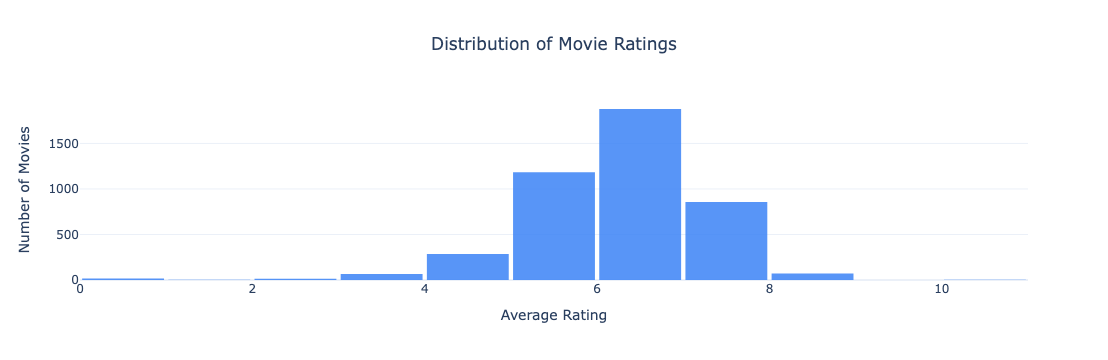

In [5]:
fig = px.histogram(
    df,
    x="vote_average",
    nbins=20,
    title="Distribution of Movie Ratings",
    color_discrete_sequence=["#3B82F6"],
    opacity=0.85
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Average Rating",
    yaxis_title="Number of Movies",
    title_x=0.5,
    bargap=0.05
)

fig.update_traces(
    hovertemplate="<b>Rating:</b> %{x}<br><b>Movies:</b> %{y}<extra></extra>"
)

fig.show()

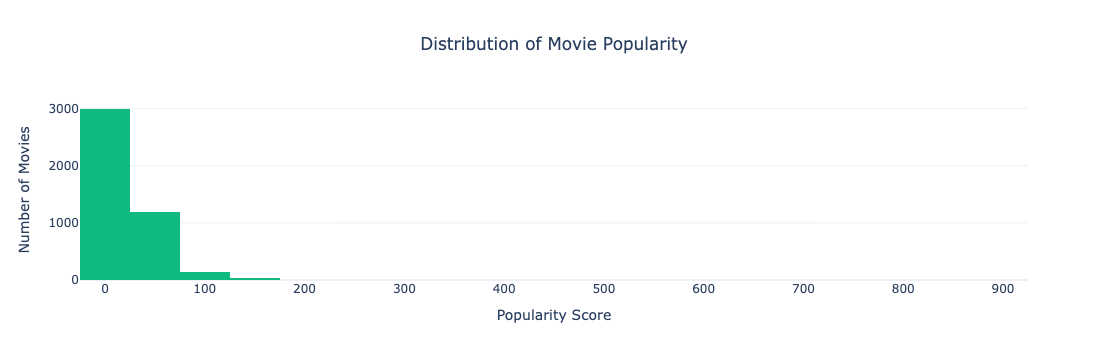

In [6]:
fig = px.histogram(
    df,
    x="popularity",
    nbins=40,
    title="Distribution of Movie Popularity",
    color_discrete_sequence=["#10B981"]
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Popularity Score",
    yaxis_title="Number of Movies"
)

fig.update_traces(
    hovertemplate="<b>Popularity:</b> %{x}<br><b>Movies:</b> %{y}<extra></extra>"
)

fig.show()

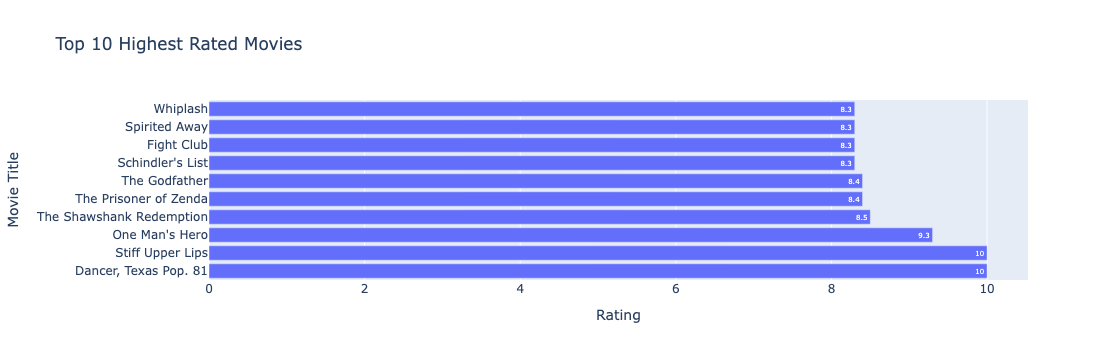

In [7]:
top_rated = df.sort_values(by="vote_average", ascending=False).head(10)

fig = px.bar(
    top_rated,
    x="vote_average",
    y="title",
    orientation="h",
    title="Top 10 Highest Rated Movies",
    text="vote_average"
)

fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Movie Title"
)

fig.show()

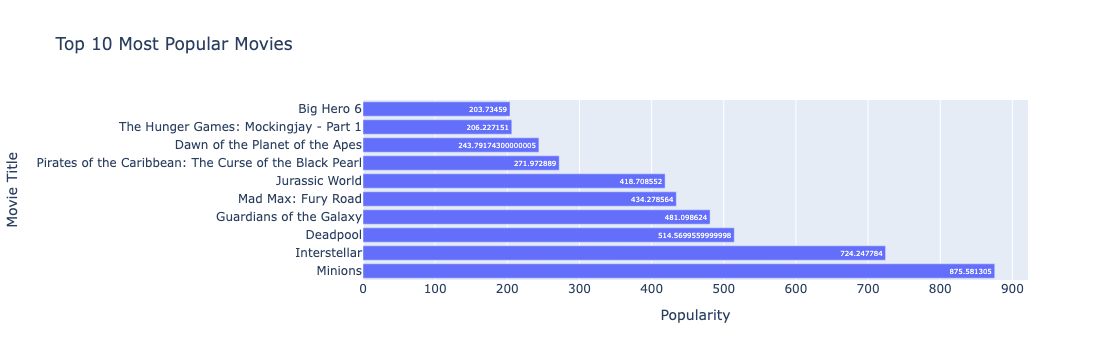

In [8]:
popular = df.sort_values(by="popularity", ascending=False).head(10)

fig = px.bar(
    popular,
    x="popularity",
    y="title",
    orientation="h",
    title="Top 10 Most Popular Movies",
    text="popularity"
)

fig.update_layout(
    xaxis_title="Popularity",
    yaxis_title="Movie Title"
)

fig.show()

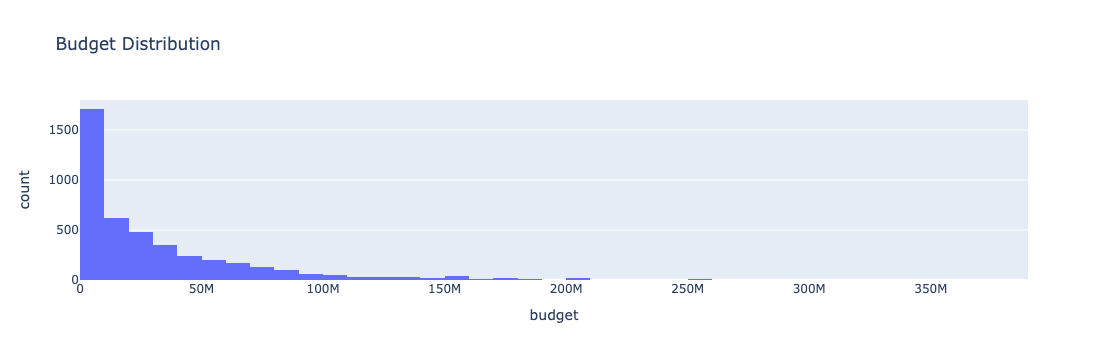

In [9]:
fig = px.histogram(

    df,

    x="budget",

    nbins=40,

    title="Budget Distribution"

)

fig.show()

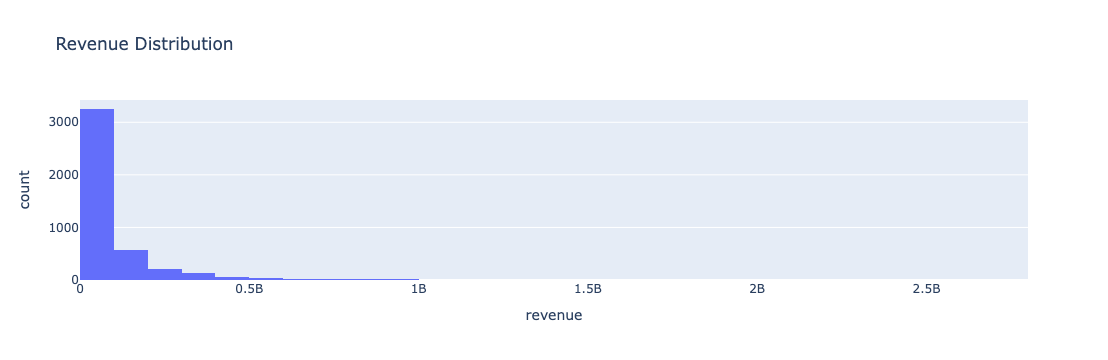

In [10]:
fig = px.histogram(
    df,
    x="revenue",
    nbins=40,
    title="Revenue Distribution"
)

fig.show()

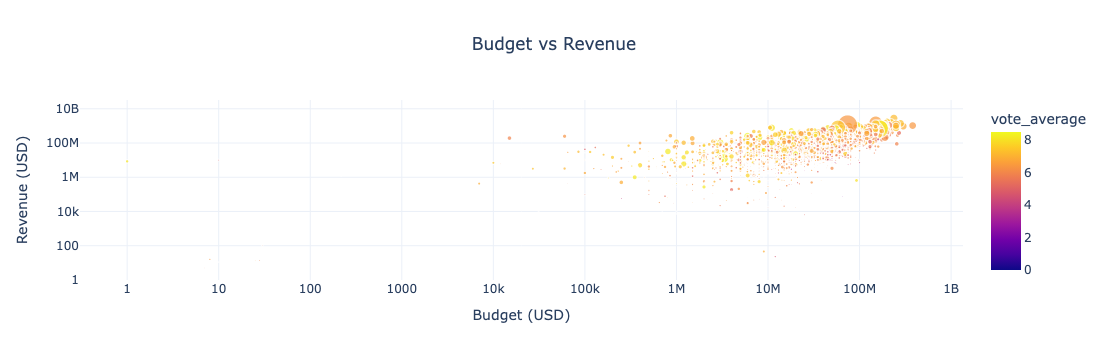

In [11]:
fig = px.scatter(
    df[(df["budget"] > 0) & (df["revenue"] > 0)],
    x="budget",
    y="revenue",
    hover_name="title",
    color="vote_average",
    size="popularity",
    title="Budget vs Revenue"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Budget (USD)",
    yaxis_title="Revenue (USD)",
    xaxis_type="log",
    yaxis_type="log"
)

fig.show()

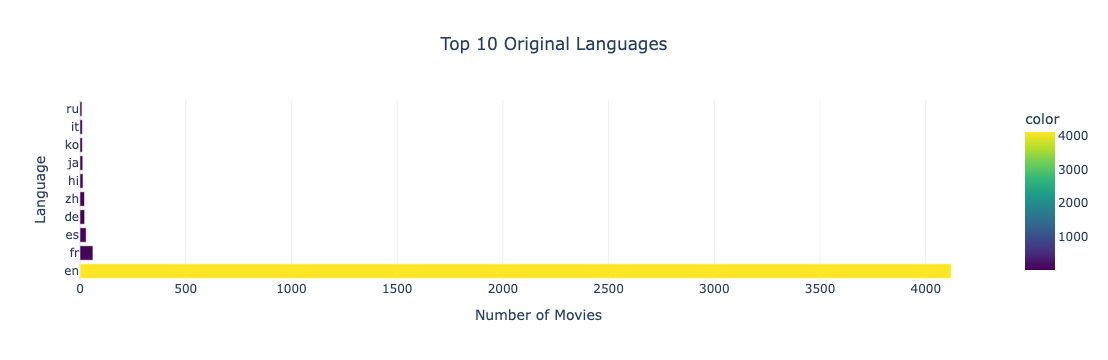

In [12]:
language = df["original_language"].value_counts().head(10)

fig = px.bar(
    x=language.values,
    y=language.index,
    orientation="h",
    title="Top 10 Original Languages",
    color=language.values,
    color_continuous_scale="Viridis"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Number of Movies",
    yaxis_title="Language"
)

fig.show()

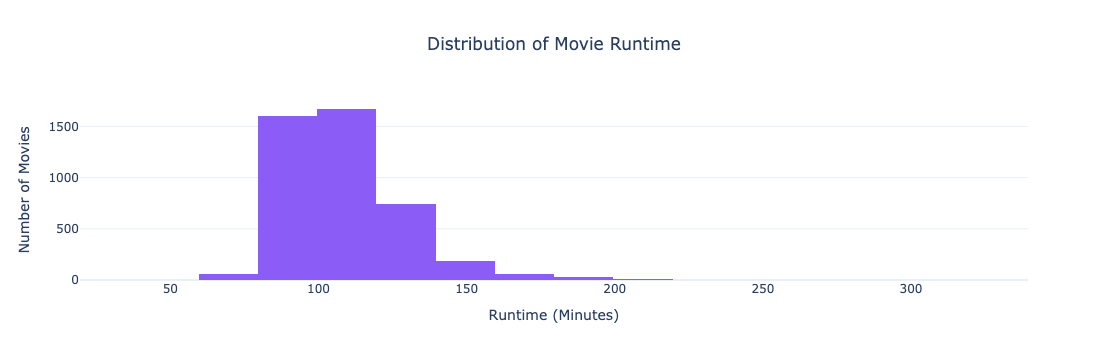

In [13]:
fig = px.histogram(
    df[df["runtime"] > 0],
    x="runtime",
    nbins=30,
    title="Distribution of Movie Runtime",
    color_discrete_sequence=["#8B5CF6"]
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Runtime (Minutes)",
    yaxis_title="Number of Movies"
)

fig.show()

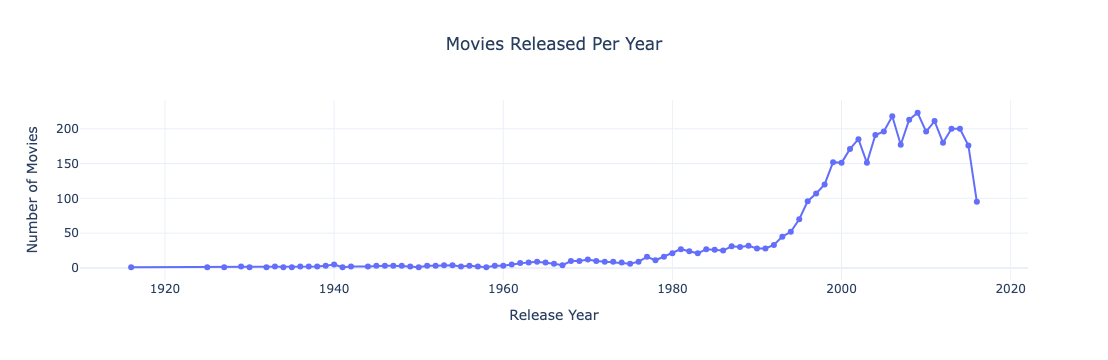

In [14]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

year = df["release_year"].value_counts().sort_index()

fig = px.line(
    x=year.index,
    y=year.values,
    markers=True,
    title="Movies Released Per Year"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Release Year",
    yaxis_title="Number of Movies"
)

fig.show()

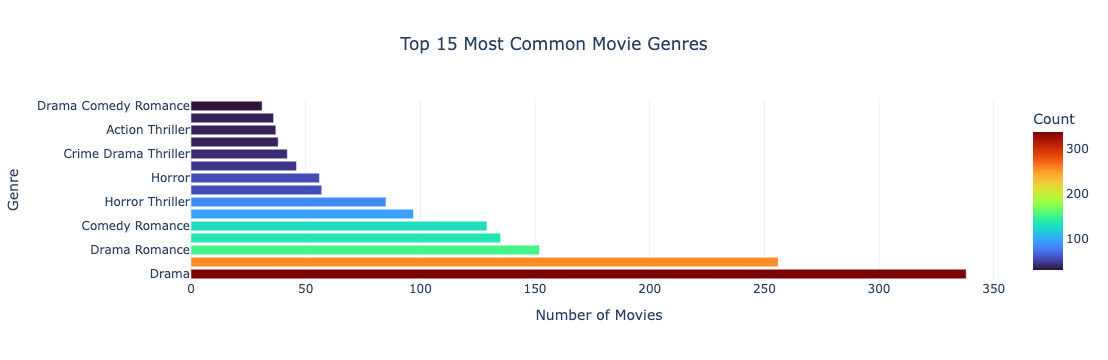

In [15]:
from collections import Counter

genre_counter = Counter()

for genres in df["genres"].dropna():
    for genre in genres.split("|"):
        genre_counter[genre.strip()] += 1

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=["Genre", "Count"]
).sort_values("Count", ascending=False).head(15)

fig = px.bar(
    genre_df,
    x="Count",
    y="Genre",
    orientation="h",
    title="Top 15 Most Common Movie Genres",
    color="Count",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Number of Movies",
    yaxis_title="Genre"
)

fig.show()

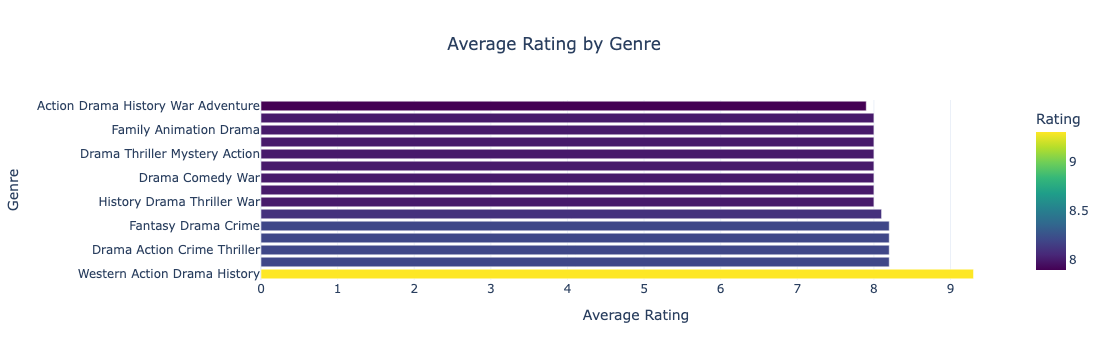

In [16]:
genre_rating = []

for _, row in df.iterrows():
    if pd.notna(row["genres"]):
        for genre in row["genres"].split("|"):
            genre_rating.append({
                "Genre": genre.strip(),
                "Rating": row["vote_average"]
            })

genre_rating = pd.DataFrame(genre_rating)

genre_rating = (
    genre_rating.groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    genre_rating,
    x="Rating",
    y="Genre",
    orientation="h",
    title="Average Rating by Genre",
    color="Rating",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Average Rating",
    yaxis_title="Genre"
)

fig.show()

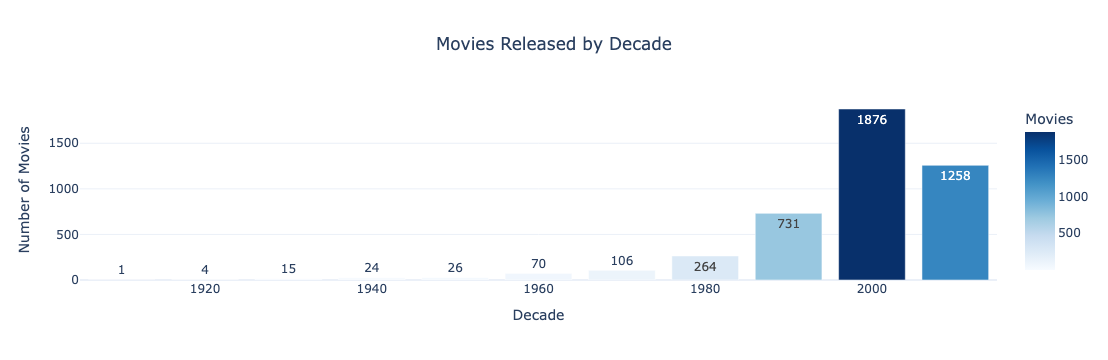

In [17]:
df["decade"] = (df["release_year"] // 10) * 10

decade = (
    df["decade"]
    .value_counts()
    .sort_index()
    .reset_index()
)

decade.columns = ["Decade", "Movies"]

fig = px.bar(
    decade,
    x="Decade",
    y="Movies",
    title="Movies Released by Decade",
    text="Movies",
    color="Movies",
    color_continuous_scale="Blues"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Decade",
    yaxis_title="Number of Movies"
)

fig.show()

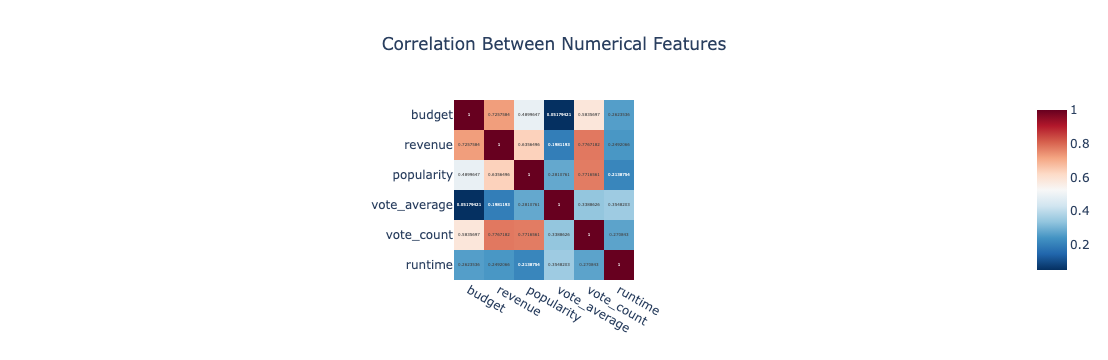

In [18]:
import plotly.express as px

corr = df[[
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count",
    "runtime"
]].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Between Numerical Features"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

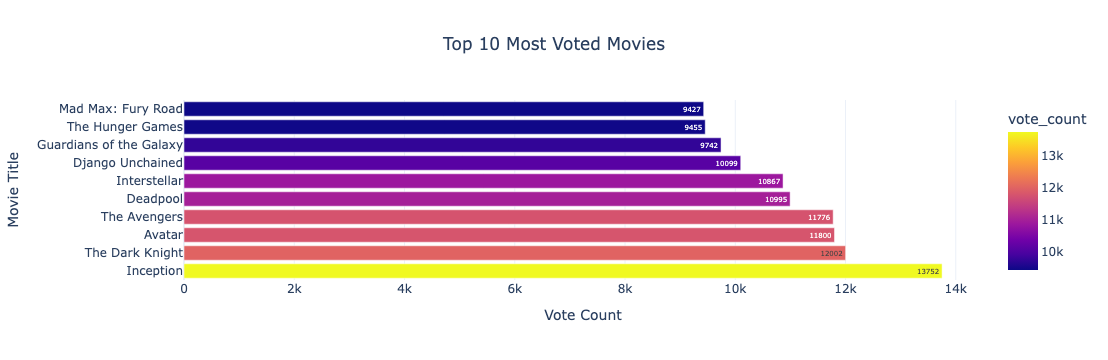

In [19]:
top_votes = (
    df.sort_values("vote_count", ascending=False)
      .head(10)
)

fig = px.bar(
    top_votes,
    x="vote_count",
    y="title",
    orientation="h",
    title="Top 10 Most Voted Movies",
    text="vote_count",
    color="vote_count",
    color_continuous_scale="Plasma"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Vote Count",
    yaxis_title="Movie Title"
)

fig.show()

# Exploratory Data Analysis Summary

## Key Findings

- Most movies are rated between **5 and 8**.
- Movie popularity is highly skewed, with only a few blockbuster titles dominating.
- Higher-budget films generally generate higher revenue.
- English is the dominant original language.
- Drama, Comedy, and Action are the most common genres.
- Ratings vary noticeably across genres.
- Movie production increased significantly after the 1990s.
- Budget, revenue, popularity, and vote count show meaningful relationships that reflect commercial success.

## Conclusion

The dataset is well suited for building a content-based movie recommendation system. The insights gained from EDA will guide feature engineering and improve recommendation quality.